Python + Google Colab: Algoritmalar ve Veri Yapıları Eğitimi (Sıfırdan İleriye)
Bölüm 17: Python’da Makine Öğrenmesi Kütüphaneleri (Scikit-Learn, TensorFlow)
17.1. Yapay Zeka ve Veri Bilimi Uygulamaları İçin Veri Yapılarının Önemi
17.2. Scikit-Learn Kütüphanesi
17.3. TensorFlow Kütüphanesi

Github Kaynagı:
https://github.com/acetinkaya/Python-Google-Colab-Algoritmalar-ve-Veri-Yapilari-Egitimi --> D17


In [ ]:
print("Merhaba, Python Veri Yapıları ve Algoritmalar / Bölüm 17")

Merhaba, Python Veri Yapıları ve Algoritmalar / Bölüm 17


In [ ]:
import sys  # import python programlama dilinde yazılıma kütüphane eklemeye yarayan bir kod blogudur.
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
from google.colab import drive # google colab - drive bağlantısı

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.chdir('/content/drive/My Drive/GoogleColab')

!pwd # bize kodun çıktısını dosya yolu olarak veren kod blogudur.

/content/drive/My Drive/GoogleColab


#Bölüm 17: Python’da Makine Öğrenmesi Kütüphaneleri (Scikit-Learn, TensorFlow)

17.1. Yapay Zeka ve Veri Bilimi Uygulamaları İçin Veri Yapılarının Önemi
Verilerin Doğru Temsili İçin
Verimli Veri Erişimi ve İşleme İçin
Algoritmaların Doğru Çalışması İçin
Modelleme ve Analiz Kolaylığı Sağlar
Gerçek Zamanlı Uygulamaların doğruluk sonucunun artmasında kritik önemi vardır
Yapay zekâ ve veri bilimi uygulamalarında veri yapıları, verinin temsil edilmesi, işlenmesi ve analiz edilmesinde temel bir rol oynar. Doğru veri yapısının seçilmesi, hem algoritmaların doğruluğunu hem de sistem performansını doğrudan etkiler.

Yapay Zeka Algoritmaları bilgisayar üzerinde iki donanım birimi üzerinde işleme alınır. Bu birimler, "CPU - (Central Processing Unit) - Merkezi İşlem Birimi" ve "GPU (Graphics Processing Unit) – Grafik İşlem Birimi" 'dır.

Genel bir bakış açısıyla CPU, bilgisayarın genel iş yükünü yönetir, programları çalıştırır ve komutları işler. Bu işlemlerle birlikte yapay zeka algoritmalarını derler. GPU, bilgisayarın işlem yükünden bağımsız paralel işlem birimleriyle yapay zeka algoritmalarını derler.

CPU'lar: Intel Core i9, AMD Ryzen 9 gibi GPU'lar: NVIDIA RTX 3090, AMD Radeon RX 6900 XT gibidir.

Hangi teknolojiyi kullanacağımızı elimizdeki verinin ölçeğine göre belirlemiz gerekmektedir.

Bir veri setinin boyutlandırılmasında kullanılan veri ölçeği kavramı:

Küçük ölçekli: 100 ile 10,000 arası veri
Orta ölçekli: 10,000 ile 100,000 arası veri
Büyük ölçekli: 100,000 ile bir milyon arası veri
Hiper ölçekli: Bir Milyon ile Bir Milyar arası veri
Exascale computing ölçekli: Bir Millar ile ... (bir trilyon)

In [ ]:
# CPU ve GPU teknolojisinin kullanımına göre olması gereken veri sayısı tablosu

import pandas as pd

tablo = {
    "Aralık": ["Küçük ölçekli", "Orta ölçekli", "Büyük ölçekli", "Hiper ölçekli", "Exascale"],
    "Veri Sayısı": ["100 - 10,000", "10,000 - 100,000", "100,000 - Milyon",  "Milyon - Milyar", "Milyar - Trilyon"],
    "CPU": ["Evet", "Evet", "Opsiyonel", "Hayır", "Hayır"],
    "GPU": ["Hayır", "Opsiyonel", "Evet", "Evet", "Evet"]
}

print(pd.DataFrame(tablo))

          Aralık       Veri Sayısı        CPU        GPU
0  Küçük ölçekli      100 - 10,000       Evet      Hayır
1   Orta ölçekli  10,000 - 100,000       Evet  Opsiyonel
2  Büyük ölçekli  100,000 - Milyon  Opsiyonel       Evet
3  Hiper ölçekli   Milyon - Milyar      Hayır       Evet
4       Exascale  Milyar - Trilyon      Hayır       Evet


#Kütüphane Kurulumunda dikkat edilmesi gereken en önemli konu:
Genel kullanım bakımından python kütüphanesi kurucağımız zaman dikkat edilmesi gereken iki yapı bulunmaktadır. Bu yapılar "pip" ve "pip3"'tür.

pip yapısı -> Python 2.x sürümlerini destekler.

pip3 yapısı -> Python 3.x sürümlerini destekler.

Bilgisayarınızda kütüphane kurulumu yaparken mutlaka python sürümünü ilk kod sürecinde kontrol etmeniz gerekmektedir. Google colab python 3 sürümü ile çalıştığı için tüm kurulacak kütüphaneler pip veya pip3 kullanımı farketmeksizin python 3 sürümüne göre kurulmaktadır.

#Bir yapay zeka modelinin başarısının tespit işlemi için kullanılan performan ölçüm metotları bulunmaktadır.
Bu kavramlar eğtim boyunca sürekli konuşacağız... İngilizce tanımları ile öğrenilmesi gerekmektedir.

Bunlar;

Mean Absolute Error (MAE): Gerçek değerler ile tahmin edilen değerler arasındaki farkların mutlak değerlerinin ortalamasıdır.

Mean Squared Error (MSE): Modelin tahminleri ile gerçek değerler arasındaki farkların karesinin ortalamasıdır.

Root Mean Squared Error (RMSE): MSE'nin kareköküdür ve tahminlerin ne kadar tutarlı olduğunu gösterir.

Mean Absolute Percentage Error (MAPE): Gerçek değerler ile tahmin edilen değerler arasındaki farkın, gerçek değere göre yüzdesel olarak ne kadar olduğunu gösterir.

R-squared (R²): Modelin hedef değişkenin varyansını ne kadar iyi açıkladığını gösterir.

Doğruluk (Accuracy): Modelin doğru sınıflandırdığı örneklerin, toplam örnek sayısına oranıdır.

Kesinlik (Precision):Modelin pozitif tahminlerinin ne kadarının gerçekten pozitif olduğunu gösterir.

Duyarlılık (Recall): Gerçek pozitif örneklerin ne kadarını modelin doğru bir şekilde tahmin edebildiğini gösterir.

F1-Score: Kesinlik ve Duyarlılık bilgilerinin harmonik ortalamasıdır. Hem yanlış pozitifler hem de yanlış negatiflerin etkisini dengeler.

Karmaşıklık Matrisi (Confusion Matrix): Modelin hangi sınıflarda ne kadar doğru veya yanlış tahmin yaptığını gösteren bir tablo.dur. Modelin tahmin performansının daha ayrıntılı bir görünümünü sağlar.

Karmaşıklık Matrisinde Kullanılan tanımlar ve kavramlar->

TP (True Positives - Doğru pozitif)

TN (True Negatives - Doğru negatif)

FP (False Positives - Yanlış pozitif)

FN (False Negatives - Yanlış negatif)

In [ ]:
import pandas as pd

# True Positive (TP), True Negative (TN), False Positive (FP), False Negative (FN)
matris_bilgisi = {
    "Gerçek Pozitif": ["Doğru Pozitif (TP)", "Yanlış Negatif (FN)"],
    "Gerçek Negatif": ["Yanlış Pozitif (FP)", "Doğru Negatif (TN)"]
}

# DataFrame oluşturma
matris = pd.DataFrame(matris_bilgisi, index=["Tahmin Pozitif", "Tahmin Negatif"])

# Tabloyu gösterme
print(matris)

                     Gerçek Pozitif       Gerçek Negatif
Tahmin Pozitif   Doğru Pozitif (TP)  Yanlış Pozitif (FP)
Tahmin Negatif  Yanlış Negatif (FN)   Doğru Negatif (TN)


Karmaşıklık matrisinden sistemin doğruluğunu bulacağımız formül ->

Dogruluk = TP+TN+FP+FN / TP+TN 'dir.

Örneğin: TP = 50, TN = 40, FP = 5, FN = 5 ise; Dogruluk = 50 + 40 + 5 + 5 / 50 + 40 --> 0.9 -> % 90 olarak hesaplanmaktadır.

%90 Model Doğruluk Oranı - %10 Modelin Hata Oranı 'dır.

Hata oranını azaltmak için->

Modelin iyileştirilmesi,
Veri sayısının arttırılması,
Eğitim adım sayısının değiştirilmesi,
Veri seti içerisindeki farklı değişlenlerin - özelliklerin algoritmaya dahil edilmesi.

In [ ]:
# Scikit-Learn kütüphanesinin sisteme dahil edilmesi ve veri setinin işleme alınması

!pip3 install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


17.2 Scikit-Learn kütüphanesi:
!pip3 install -U scikit-learn
İlk örneğimizde fetch_california_housing() veri setini Scikit-Learn kütüphanesi içerisinden alarak ilk yapay zeka uygulamamızı gerçekleştireceğiz. Bu veri setinin içeriğinde: California'daki farklı konumlardaki ev fiyatlarının verileri ve bu fiyatları etkileyen çeşitli faktörler içerir.

"fetch_california_housing" veri setinin değişken tanımları->

MedInc: Ortalama hane geliri

HouseAge: Konutların ortalama yaşı

AveRooms: Ortalama oda sayısı

AveBedrms: Ortalama yatak odası sayısı

Population: Bölgede yaşayan nüfus sayısı

AveOccup: Hane başına ortalama kişi sayısı

Latitude: Bölgenin enlem bilgisi

Longitude: Bölgenin boylam bilgisi

Target: Bölgede ortalama konut fiyatları

şimdi veri setinin kütüphane içerisinden alıyoruz..

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# California Housing veri setini yükleme
veri_seti_bilgisi = fetch_california_housing()

# Özellikleri ve hedef değişkeni almak
X = veri_seti_bilgisi.data  # Bağımsız değişkenler (özellikler)
y = veri_seti_bilgisi.target  # Bağımlı değişken (fiyatlar)

# Verileri bir DataFrame'e dönüştürme
df = pd.DataFrame(X, columns=veri_seti_bilgisi.feature_names)
df['PRICE'] = y

# İlk birkaç satırı görüntüleme
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# California Housing veri setini yükleme
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target

# Özellikler ve hedef değişkeni ayırma
X = df.drop('PRICE', axis=1)
y = df['PRICE']

# Veri setini bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=150)

# Model oluşturma
model = LinearRegression()
model.fit(X_train, y_train)

# Tahmin yapma
predictions = model.predict(X_test)
print("Tahmin Sonucları: ", predictions[:5])
print("Gerçek Değerler: ", y_test[:5].values)

# Sistemin Ortalama Hatası (MSE)
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error (MSE) Sonucu:", mse)

# Sistemin R-kare Hatası (R²)
r2 = r2_score(y_test, predictions)
print("R-squared (R²) Sonucu:", r2)

Tahmin Sonucları:  [1.60018158 2.29084462 2.6182369  0.20944944 1.23639749]
Gerçek Değerler:  [0.933 2.799 3.929 0.52  1.236]
Mean Squared Error (MSE) Sonucu: 0.5322170539831866
R-squared (R²) Sonucu: 0.5984024263886707


17.3. TensorFlow kütüphanesi:
!pip3 install tensorflow

!pip3 install tensorflow-gpu

MNIST veri seti üzerinde yapay zeka algoritmalarıyla işlemler gerçekleştireceğiz.

MNIST veri seti elle yazılmış rakamları içeren bir görüntü veri setidir. 0'dan 9'a kadar olan rakamları içeren 28x28 piksel boyutunda siyah-beyaz görüntülerden oluşmaktadır. Veri setinde toplamda 70000 adet veri bulunmaktadır. Veri setinde (0, 1, 2, ..., 9) 10 adet sınıf bulunmaktadır.

Veri Setini: Eğitim ->60000 ve Test ->10000 olmak üzere yazılım üzerinde bölmemiz gerekmektedir.

Büyük veri setlerini bölmedeki amaç, modelin aşırı öğrenme (overfitting) yapmasını önlemektir. Eğer model sadece eğitim verisi üzerinde eğitirse ve test edilseydi, model sadece o verilere "ezberci" bir şekilde süreci ele alacaktı. Bu duruma bağlı olarak modeli yeni veriler üzerinde denemelerinde başarısız sonuçlar ortaya çıkabilmektedir.

Yapay zeka modeli oluşturmada aşamalar;
Modelin Oluşturulması --> model = models.Sequential()
Flatten Katmanı -> layers.Flatten(input_shape=(28, 28))
Bu katman, 2 boyutlu (28x28) bir görüntüyü 1 boyutlu bir vektöre dönüştürür 28x28=784 boyutlu bir vektördür.

Dense Katmanı -> layers.Dense(128, activation='relu')
Bu katman, tam bağlı bir katmandır. Yani her bir nöron, bir önceki katmandaki tüm nöronlarla bağlantılıdır. Burada 128 nöron bulunmaktadır.

Aktivasyon Fonksiyonları: Relu, Sigmoid, Tanh, Leaky ReLU ve Softmax'dır.

Dropout Katmanı -> layers.Dropout(0.2)
Dropout: Bu katman, eğitim sırasında nöronların %20'sini rastgele devre dışı bırakır. Aşırı öğrenme (overfitting) sorununu azaltmak. Dropout sayesinde model belirli nöronlara çok fazla bağımlı hale gelmez. Modelin, eğitim verisini ezberlemesini (overfitting) önlemek için nöronların bazıları eğitim sırasında rastgele devre dışı bırakılır.

Çıkış Katmanı (Dense Katmanı ve Softmax Aktivasyon Fonksiyonu)
--> layers.Dense(10, activation='softmax')

Dense Katmanı: Bu katmanda 10 nöron bulunur. Bu nöronlar, 0'dan 9'a kadar olan rakamları sınıflandırmak için kullanılır (MNIST veri setinde de 10 sınıf olduğu için bu değeri 10 olarak belirliyoruz.)

Softmax fonksiyonu, giriş değerlerini olasılıklara çevirir. Her bir nöronun çıkışı 0 ile 1 arasında olacak şekilde normalize edilir ve tüm çıkışların toplamı 1 olur.

In [ ]:
!pip3 install tensorflow


In [ ]:


# TensorFlow kütüphanesinin sisteme dahil edilmesi ve veri setinin işleme alınması

!pip3 install pydot
!apt-get install graphviz

# Bu iki kütüphane ile oluşturulan yapay zeka modelinin yapısını çıktı alabileceğiz.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import plot_model

(x_train, y_train), (x_test, y_test) = mnist.load_data() # MNIST veri setini yükleme
x_train, x_test = x_train / 255.0, x_test / 255.0
!pwd

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
/content/drive/MyDrive/GoogleColab


In [ ]:
model = models.Sequential([ # Modeli oluşturma
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Modelin eğitim süreci
model.compile() --> modeli eğitim için hazır hale getiriyoruz.
Optimizasyon Algoritması -> optimizer='adam'
Kayıp Fonksiyonu -> loss='...................'
sparse_categorical_crossentropy: Çoklu sınıflandırma problemlerinde kullanılır.

binary_crossentropy: İkili sınıflandırma problemlerinde kullanılır

categorical_crossentropy: Çok sınıflı sınıflandırma problemlerinde kullanılır.

mean_squared_error (MSE): Tahmin edilen değer ile gerçek değer arasındaki farkın karesinin ortalamasını alır.

Başarı değerlerinin elde edilmesi --> metrics=['accuracy']
Accuracy -> Doğruluk
Precision -> Kesinlik
Recall -> Duyarlılık
F1-Score


In [ ]:
model.compile(optimizer='adam', # Modeli derleme
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9802 - loss: 0.0613
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9806 - loss: 0.0580
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9804 - loss: 0.0590
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9821 - loss: 0.0531
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9833 - loss: 0.0501


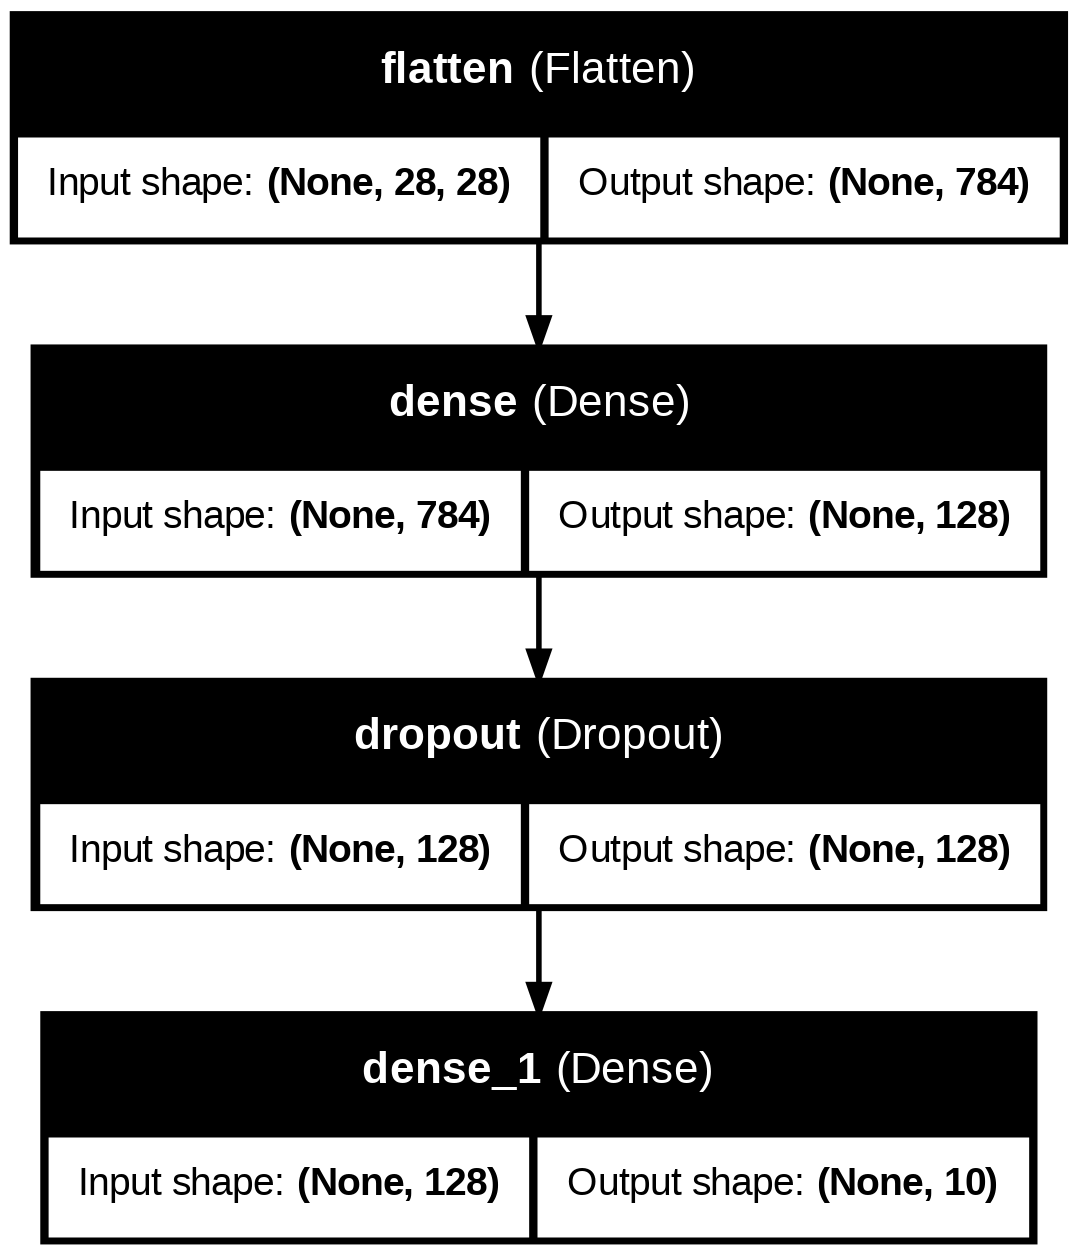

In [ ]:
model.fit(x_train, y_train, epochs=5) # Modeli Eğitilmesi Adımı

# Modeli görselleştirmek ve çalışma alanına kaydetmek için plot_model kullanımı
plot_model(model, to_file='yz_model/yz_tensoflow_model_ciktisi.png', show_shapes=True, show_layer_names=True) # Modelin Çıktısı
# sistemin hata verebileceği en temel noktadır. İşlemlerde dikkat!!!

In [ ]:
# Test seti üzerinde modelin performansını değerlendirme

hata_oranı, basarı_oranı = model.evaluate(x_test, y_test, verbose=2)

print(" Modelin Doğruluk Oranı: %", 100*basarı_oranı)
print(" Modelin Hata Oranı: %", (100-100*basarı_oranı))

313/313 - 2s - 5ms/step - accuracy: 0.9787 - loss: 0.0747
 Modelin Doğruluk Oranı: % 97.86999821662903
 Modelin Hata Oranı: % 2.1300017833709717
